In [125]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

pd.set_option('display.max_rows', 500)


# Downloading dataset

In [126]:
df_train = pd.read_csv('data/train.csv')
X_test = pd.read_csv('data/test.csv')

# Data analysis

**df_train**

In [127]:
df_train.shape

(1460, 81)

In [128]:
df_train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [129]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [130]:
df_train.describe(include='object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


**X_test**

In [131]:
X_test.shape

(1459, 80)

In [132]:
X_test.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
5,1466,60,RL,75.0,10000,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
6,1467,20,RL,NaN,7980,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,500,3,2010,WD,Normal
7,1468,60,RL,63.0,8402,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
8,1469,20,RL,85.0,10176,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal
9,1470,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,4,2010,WD,Normal


In [133]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [134]:
df_train.dtypes.value_counts()

object     43
int64      35
float64     3
dtype: int64

**Visualizing the distribution of SalePrice**

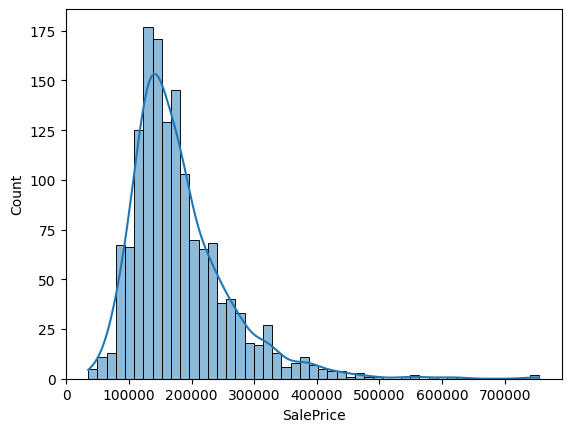

In [135]:
sns.histplot(df_train['SalePrice'], kde=True)
plt.show()

In [136]:
print(f"Skewness: {df_train['SalePrice'].skew()} \nKurtosis: {df_train['SalePrice'].kurtosis()}")

Skewness: 1.8828757597682129 
Kurtosis: 6.536281860064529


**Correlation matrix**

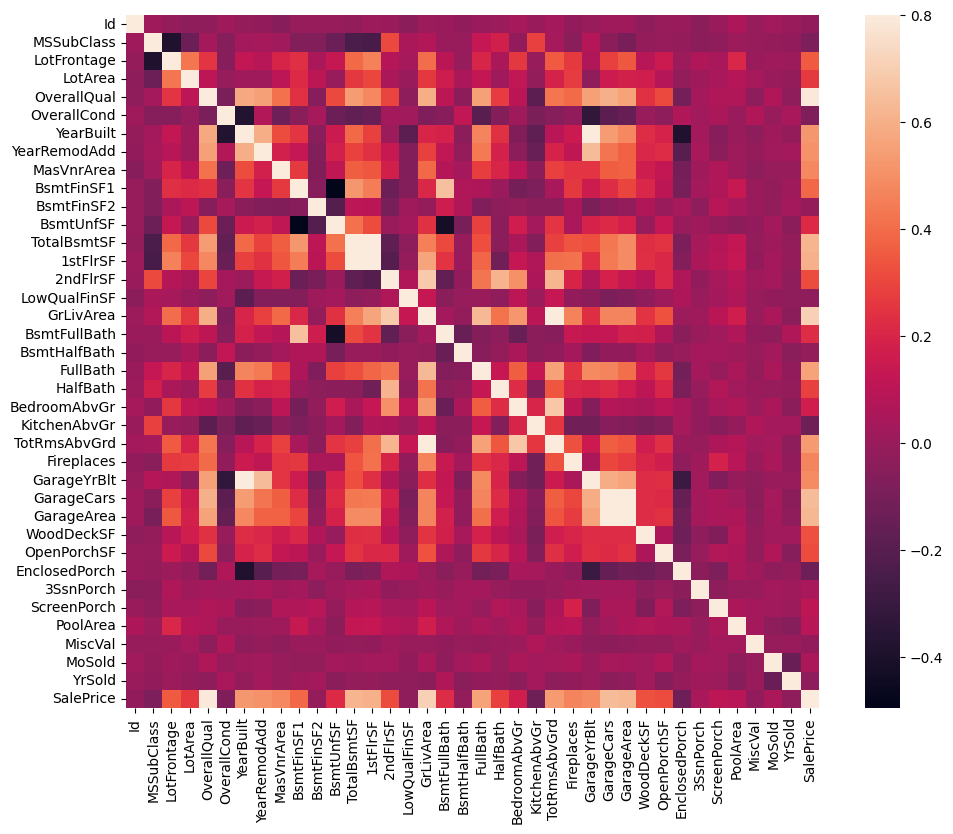

In [137]:
corrmat = df_train.corr(numeric_only=True)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()

**Top 10 variables**

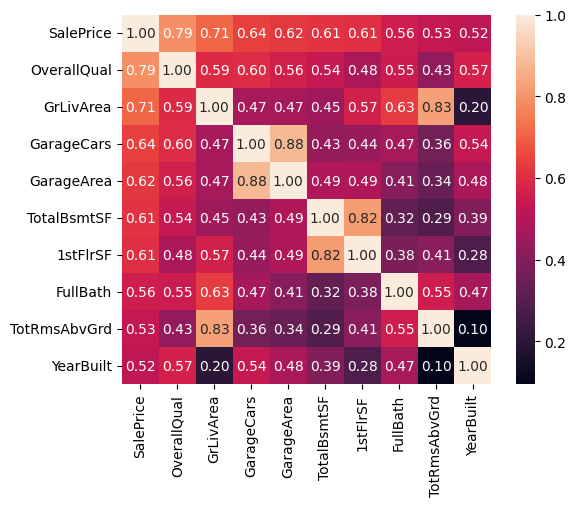

In [138]:
cols = corrmat.nlargest(10, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df_train[cols].values.T)
heat = sns.heatmap(cm, cbar = True, annot = True, square = True, fmt = '.2f', yticklabels = cols.values, xticklabels = cols.values)

**Filling missing values**

In [139]:
columns_with_na = df_train.isna().sum() > 0
df_train.loc[:,columns_with_na.values].isna().sum()

LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [140]:
for df in [df_train, X_test]:
    # Fill numeric columns with their mean value
    num_cols = df.select_dtypes(exclude='object').columns
    for col in num_cols:
        df[col].fillna(df[col].mean(), inplace=True)

    # Fill categorical columns with their mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [141]:
columns_with_na = df_train.isna().sum() > 0
df_train.loc[:,columns_with_na.values].isna().sum()

Series([], dtype: float64)

**Splitting df into target variable and features**

In [142]:
X = df_train.copy()
y = X.pop('SalePrice')

In [143]:
for df in [X, X_test]:
    for colname in df.select_dtypes("object"):
        df[colname], _ = df[colname].factorize()

# Feature engineering

In [144]:
X.drop('Id', axis=1, inplace=True)
X_test.drop('Id', axis=1, inplace=True)

**Discrete features**

In [145]:
discrete_features = list(X.select_dtypes(include='int').columns)
discrete_features

['MSSubClass',
 'MSZoning',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'Po

In [146]:
X.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [147]:
X.columns.isin(discrete_features)

array([ True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [148]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(
        X,
        y, 
        discrete_features = X.columns.isin(discrete_features)
    )
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)

mi_scores

OverallQual      5.738747e-01
Neighborhood     5.311961e-01
GarageArea       4.973539e-01
GrLivArea        4.312287e-01
YearBuilt        4.077902e-01
TotalBsmtSF      3.971670e-01
LotArea          3.958383e-01
GarageCars       3.698764e-01
ExterQual        3.313579e-01
KitchenQual      3.289651e-01
BsmtQual         3.179082e-01
GarageYrBlt      2.914173e-01
MSSubClass       2.858203e-01
1stFlrSF         2.807261e-01
YearRemodAdd     2.722092e-01
FullBath         2.633813e-01
GarageFinish     2.414861e-01
TotRmsAbvGrd     2.206876e-01
Foundation       1.983199e-01
LotFrontage      1.934362e-01
OpenPorchSF      1.864912e-01
Fireplaces       1.752770e-01
HeatingQC        1.687944e-01
Exterior2nd      1.670014e-01
2ndFlrSF         1.662548e-01
BsmtFinSF1       1.547086e-01
BsmtFinType1     1.454877e-01
Exterior1st      1.428147e-01
MSZoning         1.308740e-01
BsmtUnfSF        1.250941e-01
GarageType       1.236577e-01
OverallCond      1.139742e-01
WoodDeckSF       1.108854e-01
MasVnrArea

In [149]:
mi_scores.index

Index(['OverallQual', 'Neighborhood', 'GarageArea', 'GrLivArea', 'YearBuilt',
       'TotalBsmtSF', 'LotArea', 'GarageCars', 'ExterQual', 'KitchenQual',
       'BsmtQual', 'GarageYrBlt', 'MSSubClass', '1stFlrSF', 'YearRemodAdd',
       'FullBath', 'GarageFinish', 'TotRmsAbvGrd', 'Foundation', 'LotFrontage',
       'OpenPorchSF', 'Fireplaces', 'HeatingQC', 'Exterior2nd', '2ndFlrSF',
       'BsmtFinSF1', 'BsmtFinType1', 'Exterior1st', 'MSZoning', 'BsmtUnfSF',
       'GarageType', 'OverallCond', 'WoodDeckSF', 'MasVnrArea', 'MasVnrType',
       'HouseStyle', 'SaleType', 'SaleCondition', 'FireplaceQu', 'HalfBath',
       'LotShape', 'BedroomAbvGr', 'CentralAir', 'BsmtExposure', 'PavedDrive',
       'Electrical', 'BldgType', 'LandContour', 'EnclosedPorch', 'Condition1',
       'BsmtFullBath', 'BsmtCond', 'KitchenAbvGr', 'GarageCond', 'ScreenPorch',
       'RoofStyle', 'ExterCond', 'Heating', 'GarageQual', 'LotConfig',
       'BsmtHalfBath', 'Fence', 'BsmtFinType2', 'Alley', 'RoofMatl',
     

In [150]:
mi_scores.values

array([5.73874719e-01, 5.31196103e-01, 4.97353877e-01, 4.31228734e-01,
       4.07790198e-01, 3.97167047e-01, 3.95838256e-01, 3.69876427e-01,
       3.31357938e-01, 3.28965096e-01, 3.17908223e-01, 2.91417350e-01,
       2.85820346e-01, 2.80726137e-01, 2.72209215e-01, 2.63381333e-01,
       2.41486142e-01, 2.20687604e-01, 1.98319851e-01, 1.93436218e-01,
       1.86491244e-01, 1.75277032e-01, 1.68794408e-01, 1.67001422e-01,
       1.66254809e-01, 1.54708551e-01, 1.45487738e-01, 1.42814706e-01,
       1.30874020e-01, 1.25094124e-01, 1.23657693e-01, 1.13974220e-01,
       1.10885392e-01, 1.01141398e-01, 9.92755881e-02, 8.50061588e-02,
       8.12466149e-02, 8.11033860e-02, 8.10070578e-02, 7.93048008e-02,
       7.65428972e-02, 7.13005032e-02, 6.45614381e-02, 5.90369941e-02,
       4.95911443e-02, 4.81343006e-02, 4.00268121e-02, 2.66308304e-02,
       2.48374553e-02, 2.44057930e-02, 2.43116017e-02, 2.37648699e-02,
       2.28502282e-02, 1.98516661e-02, 1.74019812e-02, 1.59930727e-02,
      

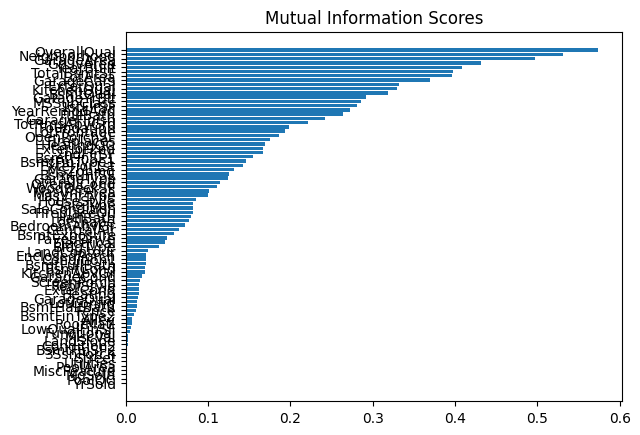

In [151]:
def plot_mi_scores(mi_scores):
    mi_scores = mi_scores.sort_values(ascending=True)
    width = np.arange(len(mi_scores))
    ticks = list(mi_scores.index)
    plt.barh(width, mi_scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

plot_mi_scores(mi_scores)

**Scaling data**

In [152]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X))
X_test = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)

# Model

**Linear Regression**

In [153]:
linear_regression = LinearRegression()
linear_regression.fit(X, y)

LinearRegression()

In [154]:
linear_regression.score(X, y)

0.8468762566798818

In [155]:
y_pred_linear_regression = linear_regression.predict(X_test)
y_pred_linear_regression

e:\paolo\Program Files (x86)\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([105030.74661929, 162949.24280522, 169714.41278404, ...,
       135389.73336385,  99100.09034104, 239450.3749726 ])

In [156]:
linear_regression_submission = pd.DataFrame({
        "Id": range(1461, 2920),
        "SalePrice": y_pred_linear_regression.round(2)
    })

linear_regression_submission

,Id,SalePrice
0,1461,105030.75
1,1462,162949.24
2,1463,169714.41
3,1464,193851.60
4,1465,198952.40
...,...,...
1454,2915,42761.00
1455,2916,53951.44
1456,2917,135389.73
1457,2918,99100.09


In [157]:
linear_regression_submission.to_csv('linear_regression_submission.csv', index = False)

**Random fortest**

In [158]:
random_forest = RandomForestRegressor(random_state=0)
random_forest.fit(X, y)

RandomForestRegressor(random_state=0)

In [159]:
random_forest.score(X, y)

0.9806861762097328

In [160]:
y_pred_random_forest = random_forest.predict(X_test)
y_pred_random_forest

e:\paolo\Program Files (x86)\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


array([132624.08, 155978.  , 178497.8 , ..., 155564.74, 112748.  ,
       235891.36])

In [161]:
random_forest_submission = pd.DataFrame({
        "Id": range(1461, 2920),
        "SalePrice": y_pred_random_forest
    })

random_forest_submission

,Id,SalePrice
0,1461,132624.08
1,1462,155978.00
2,1463,178497.80
3,1464,187124.12
4,1465,201968.93
...,...,...
1454,2915,80803.00
1455,2916,85617.77
1456,2917,155564.74
1457,2918,112748.00


In [162]:
random_forest_submission.to_csv('random_forest_submission.csv', index = False)